In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# загружаем рабочий датасет
DATA = Path.cwd().parent / 'data' / 'processed' / 'dzen_articles.csv'
df = pd.read_csv(DATA)

print("Размер:", df.shape)
print("Доход:", df['Суммарный доход'].sum().round(2), "₽")
print("\nТипы данных:")
print(df.dtypes.value_counts())

Размер: (198, 26)
Доход: 50702.42 ₽

Типы данных:
int64      10
float64    10
str         6
Name: count, dtype: int64


In [2]:
df['Дата публикации'] = pd.to_datetime(df['Дата публикации'], errors='coerce')

In [3]:
# --- 1. Категория ---
def categorize(title):
    t = str(title).lower()
    if 'трансферы' in t or 'трансфер' in t:
        return 'Трансферы'
    if any(w in t for w in ['ссср', 'чемпионат ссср', 'кубок ссср', 'первенство советского']):
        return 'История СССР'
    if any(w in t for w in ['тур рпл', 'итоги', 'обзор', 'туров', 'матч', 'перед матчем']):
        return 'Обзоры матчей'
    if any(w in t for w in ['сборная', 'сборной', 'сборную']):
        return 'Сборная России'
    if any(w in t for w in ['слухи', 'может', 'интересен', 'хочет']):
        return 'Слухи и мнения'
    if any(w in t for w in ['все победители', 'таблица', 'статистика', 'лучшие']):
        return 'Статистика'
    if any(w in t for w in ['почему', 'разбор', 'анализ', 'главные', 'выводы']):
        return 'Аналитика'
    return 'Другое'

df['category'] = df['Публикация'].apply(categorize)

# --- 2. Топ-клуб ---
top_clubs = ['ЦСКА', 'Спартак', 'Зенит']
df['has_top_club'] = df['Публикация'].apply(
    lambda t: int(any(c.lower() in str(t).lower() for c in top_clubs))
)

# --- 3. Конкретный клуб (первый упомянутый) ---
all_clubs = ['ЦСКА', 'Спартак', 'Зенит', 'Краснодар', 'Локомотив', 
             'Динамо', 'Ростов', 'Рубин', 'Ахмат', 'Балтика', 'Акрон', 'Факел']

def first_club(title):
    t = str(title).lower()
    for c in all_clubs:
        if c.lower() in t:
            return c
    return 'Нет клуба'

df['primary_club'] = df['Публикация'].apply(first_club)

# --- 4. Временные фичи ---
df['month'] = df['Дата публикации'].dt.month
df['weekday'] = df['Дата публикации'].dt.weekday  # 0=пн, 6=вс
df['hour'] = df['Дата публикации'].dt.hour
df['is_transfer_window'] = df['month'].isin([1, 2, 6, 7, 8]).astype(int)

# --- 5. Признаки заголовка ---
df['title_length'] = df['Публикация'].str.len()
df['title_words'] = df['Публикация'].str.split().str.len()
df['has_slash'] = df['Публикация'].str.contains('/', regex=False).astype(int)
df['has_rumor'] = df['Публикация'].str.lower().str.contains(
    'может|интересен|слухи|хочет|собирается', regex=True
).astype(int)
df['has_number'] = df['Публикация'].str.contains(r'\d', regex=True).astype(int)

# --- 6. Log-трансформация таргета (доход сильно скошен) ---
df['log_income'] = np.log1p(df['Суммарный доход'])

print("Фичи созданы. Размер:", df.shape)
print("\nНовые колонки:", [c for c in df.columns if c not in ['Публикация', 'Ссылка на публикацию']][-15:])

Фичи созданы. Размер: (198, 36)

Новые колонки: ['hour', 'month', 'CTR_clean', 'CR_clean', 'ER_clean', 'category', 'has_top_club', 'primary_club', 'is_transfer_window', 'title_length', 'title_words', 'has_slash', 'has_rumor', 'has_number', 'log_income']


In [4]:
# проверяем распределение категорий
print("=== Категории ===")
print(df['category'].value_counts())

print("\n=== Клубы (primary) ===")
print(df['primary_club'].value_counts())

print("\n=== Медиана дохода по категориям ===")
print(df.groupby('category')['Суммарный доход'].agg(['count', 'median', 'mean']).round(1).sort_values('median', ascending=False))

print("\n=== Корреляции с доходом (log) ===")
num_cols = ['title_length', 'title_words', 'has_slash', 'has_rumor', 
            'has_number', 'month', 'weekday', 'hour', 'has_top_club', 'is_transfer_window']
corrs = df[num_cols + ['log_income']].corr()['log_income'].drop('log_income').sort_values()
print(corrs.round(3))

=== Категории ===
category
Трансферы         81
Другое            65
История СССР      36
Обзоры матчей      5
Сборная России     5
Слухи и мнения     4
Аналитика          1
Статистика         1
Name: count, dtype: int64

=== Клубы (primary) ===
primary_club
Нет клуба    55
Спартак      41
ЦСКА         28
Зенит        19
Краснодар    13
Локомотив    12
Динамо       11
Рубин         6
Балтика       4
Ахмат         4
Акрон         3
Ростов        1
Факел         1
Name: count, dtype: int64

=== Медиана дохода по категориям ===
                count  median    mean
category                             
Аналитика           1  1223.2  1223.2
Слухи и мнения      4   452.1   458.7
Трансферы          81   246.5   341.7
История СССР       36   106.3   144.6
Обзоры матчей       5    82.1   208.1
Другое             65    43.8   209.1
Статистика          1    29.5    29.5
Сборная России      5    12.0    19.7

=== Корреляции с доходом (log) ===
month                -0.062
hour                 -0.0

In [5]:
# полная таблица корреляций с log_income
num_cols = ['title_length', 'title_words', 'has_slash', 'has_rumor', 
            'has_number', 'month', 'weekday', 'hour', 'has_top_club', 
            'is_transfer_window']

corrs = df[num_cols + ['log_income']].corr()['log_income'].drop('log_income').sort_values()

print("=== Корреляции с log(доход) ===")
for col, val in corrs.items():
    strength = '🟢' if abs(val) > 0.2 else '🟡' if abs(val) > 0.1 else '⚪'
    print(f"{strength} {col:25s} {val:+.3f}")

=== Корреляции с log(доход) ===
⚪ month                     -0.062
⚪ hour                      -0.029
⚪ has_number                +0.022
⚪ is_transfer_window        +0.030
⚪ weekday                   +0.083
🟡 has_top_club              +0.102
🟡 has_rumor                 +0.178
🟢 has_slash                 +0.247
🟢 title_words               +0.275
🟢 title_length              +0.284


In [6]:
# сортируем по дате
df = df.sort_values('Дата публикации').reset_index(drop=True)

# split по времени: 80% train, 20% test
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

print(f"Train: {len(train)} статей ({train['Дата публикации'].min().date()} → {train['Дата публикации'].max().date()})")
print(f"Test:  {len(test)} статей ({test['Дата публикации'].min().date()} → {test['Дата публикации'].max().date()})")
print(f"\nДоход в train: {train['Суммарный доход'].sum():.2f} ₽")
print(f"Доход в test:  {test['Суммарный доход'].sum():.2f} ₽")
print(f"Средний доход: train = {train['Суммарный доход'].mean():.0f} ₽, test = {test['Суммарный доход'].mean():.0f} ₽")

Train: 158 статей (2024-11-12 → 2026-07-28)
Test:  40 статей (2026-07-30 → 2026-09-15)

Доход в train: 34871.00 ₽
Доход в test:  15831.42 ₽
Средний доход: train = 221 ₽, test = 396 ₽


In [7]:
# список фич
num_features = [
    'title_length', 'title_words', 'has_slash', 'has_rumor', 'has_number',
    'has_top_club', 'is_transfer_window', 'month', 'weekday', 'hour'
]
cat_features = ['category', 'primary_club']

# целевая — log(доход)
target = 'log_income'

# собираем X и y
X_train = train[num_features + cat_features].copy()
y_train = train[target].copy()
X_test = test[num_features + cat_features].copy()
y_test = test[target].copy()

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("\nКатегориальные фичи:", cat_features)
print("Числовые фичи:     ", len(num_features))

X_train: (158, 12)
X_test:  (40, 12)

Категориальные фичи: ['category', 'primary_club']
Числовые фичи:      10


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
    ]
)

print("Препроцессор готов")

Препроцессор готов


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# пайплайн
lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr.fit(X_train, y_train)

# предсказания (в log-шкале)
y_pred_lr = lr.predict(X_test)

# возвращаем в исходный масштаб (рубли)
y_test_rub = np.expm1(y_test)
y_pred_lr_rub = np.expm1(y_pred_lr)

# метрики
mae = mean_absolute_error(y_test_rub, y_pred_lr_rub)
rmse = np.sqrt(mean_squared_error(y_test_rub, y_pred_lr_rub))
r2 = r2_score(y_test, y_pred_lr)  # R² считаем в log-шкале, так честнее

print("=== Linear Regression (baseline) ===")
print(f"MAE:  {mae:.2f} ₽")
print(f"RMSE: {rmse:.2f} ₽")
print(f"R² (log): {r2:.4f}")
print(f"\nСредний доход в test: {y_test_rub.mean():.0f} ₽")
print(f"Медиана в test:        {y_test_rub.median():.0f} ₽")

=== Linear Regression (baseline) ===
MAE:  396.54 ₽
RMSE: 559.11 ₽
R² (log): -2.1861

Средний доход в test: 396 ₽
Медиана в test:        306 ₽


d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [10]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

# Проверим, как меняется средний доход по фолдам
for i, (train_idx, test_idx) in enumerate(tscv.split(df)):
    tr = df.iloc[train_idx]
    te = df.iloc[test_idx]
    print(f"Fold {i+1}: train={len(tr)} (avg {tr['Суммарный доход'].mean():.0f}₽), "
          f"test={len(te)} (avg {te['Суммарный доход'].mean():.0f}₽)")

Fold 1: train=33 (avg 80₽), test=33 (avg 108₽)
Fold 2: train=66 (avg 94₽), test=33 (avg 226₽)
Fold 3: train=99 (avg 138₽), test=33 (avg 277₽)
Fold 4: train=132 (avg 173₽), test=33 (avg 463₽)
Fold 5: train=165 (avg 231₽), test=33 (avg 382₽)


In [11]:
# более детально: доход по месяцам
monthly = df.groupby(df['Дата публикации'].dt.to_period('M')).agg(
    n=('Публикация', 'count'),
    avg_income=('Суммарный доход', 'mean'),
    median_income=('Суммарный доход', 'median'),
    total=('Суммарный доход', 'sum')
).round(1)
print(monthly)

                  n  avg_income  median_income   total
Дата публикации                                       
2024-11           1         0.4            0.4     0.4
2025-06           7        28.6            0.1   199.8
2025-07           5         0.1            0.1     0.6
2025-08          10        19.9            0.8   199.0
2025-09          17       165.3          114.7  2809.4
2025-10           9       206.4          130.2  1857.6
2025-11          15        72.5           52.9  1087.4
2025-12          11       127.7           47.4  1404.6
2026-01          17       229.3          145.7  3897.4
2026-02          12       268.2          178.7  3218.7
2026-03          12        62.0           35.0   744.1
2026-04           5       189.2           78.2   945.9
2026-05           9       517.6          246.5  4658.4
2026-06          15       608.1          527.6  9121.9
2026-07          15       444.8          283.0  6672.5
2026-08          23       418.9          317.8  9633.8
2026-09   

In [12]:
from sklearn.model_selection import cross_val_score

# TimeSeriesSplit + cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# для регрессии используем отрицательный MAE
scores = cross_val_score(
    rf, X_train_full := df[num_features + cat_features], 
    df[target], 
    cv=tscv, 
    scoring='neg_mean_absolute_error'
)

print("MAE по фолдам:", (-scores).round(3))
print(f"Средний MAE (log): {(-scores).mean():.3f}")

NameError: name 'rf' is not defined

In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Создаём и обучаем Random Forest
rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 2. Метрики в log-шкале
r2_rf = r2_score(y_test, y_pred_rf)

# 3. Метрики в рублях
y_pred_rf_rub = np.expm1(y_pred_rf)
mae_rf = mean_absolute_error(y_test_rub, y_pred_rf_rub)
rmse_rf = np.sqrt(mean_squared_error(y_test_rub, y_pred_rf_rub))

print("=== Random Forest ===")
print(f"R² (log): {r2_rf:.4f}")
print(f"MAE (руб): {mae_rf:.2f} ₽")
print(f"RMSE (руб): {rmse_rf:.2f} ₽")
print(f"\nСредний доход в test: {y_test_rub.mean():.0f} ₽")
print(f"Медиана в test:        {y_test_rub.median():.0f} ₽")


=== Random Forest ===
R² (log): -2.0278
MAE (руб): 329.73 ₽
RMSE (руб): 468.48 ₽

Средний доход в test: 396 ₽
Медиана в test:        306 ₽


d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [14]:
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

# берём весь df, а не X_train
X_full = df[num_features + cat_features]
y_full = df[target]

tscv = TimeSeriesSplit(n_splits=5)

# считаем MAE в log-шкале
mae_scores = -cross_val_score(
    rf, X_full, y_full, 
    cv=tscv, 
    scoring='neg_mean_absolute_error'
)

print("=== TimeSeriesSplit: MAE (log) по фолдам ===")
for i, score in enumerate(mae_scores):
    print(f"Fold {i+1}: {score:.4f}")
print(f"\nСредний MAE (log): {mae_scores.mean():.4f}")
print(f"Стандартное отклонение: {mae_scores.std():.4f}")

# R² тоже
r2_scores = cross_val_score(rf, X_full, y_full, cv=tscv, scoring='r2')
print(f"\n=== R² по фолдам ===")
for i, score in enumerate(r2_scores):
    print(f"Fold {i+1}: {score:.4f}")
print(f"\nСредний R²: {r2_scores.mean():.4f}")

d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


=== TimeSeriesSplit: MAE (log) по фолдам ===
Fold 1: 1.1628
Fold 2: 2.9894
Fold 3: 1.9455
Fold 4: 3.1730
Fold 5: 1.4241

Средний MAE (log): 2.1390
Стандартное отклонение: 0.8116


d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



=== R² по фолдам ===
Fold 1: -0.1275
Fold 2: -3.3595
Fold 3: -1.0295
Fold 4: -5.7187
Fold 5: -1.4198

Средний R²: -2.3310


d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


               feature  importance
          title_length    0.273573
                 month    0.166320
                  hour    0.144238
               weekday    0.094144
           title_words    0.071108
    is_transfer_window    0.056012
             has_rumor    0.029989
    category_Трансферы    0.029072
primary_club_Нет клуба    0.028239
     primary_club_ЦСКА    0.027014
             has_slash    0.017676
          has_top_club    0.015679
            has_number    0.014391
  primary_club_Спартак    0.009841
primary_club_Краснодар    0.007103


C:\Users\admin\AppData\Local\Temp\ipykernel_384\217780659.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')


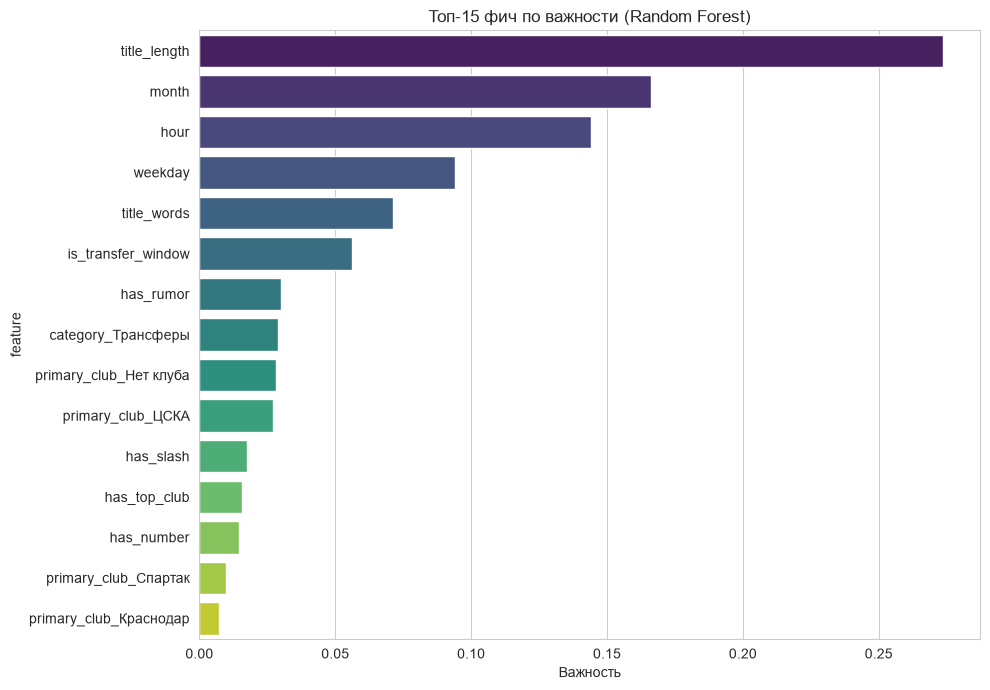

In [15]:
# получаем имена фич после OHE
feature_names = (
    num_features +
    list(rf.named_steps['preprocessor']
         .named_transformers_['cat']
         .get_feature_names_out(cat_features))
)

importances = rf.named_steps['model'].feature_importances_

imp_df = (
    pd.DataFrame({'feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .head(15)
)

print(imp_df.to_string(index=False))

# график
plt.figure(figsize=(10, 7))
sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
plt.title('Топ-15 фич по важности (Random Forest)')
plt.xlabel('Важность')
plt.tight_layout()
plt.savefig(Path.cwd().parent / 'images' / 'dzen_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# 1. Создаём целевую переменную
threshold = df['Суммарный доход'].quantile(0.8)
df['is_hit'] = (df['Суммарный доход'] >= threshold).astype(int)

print(f"Порог топ-20%: {threshold:.2f} ₽")
print(df['is_hit'].value_counts())

# 2. Заново split по времени (уже сортировано по дате)
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

X_train = train[num_features + cat_features]
y_train = train['is_hit']
X_test = test[num_features + cat_features]
y_test = test['is_hit']

print(f"\nTrain: {len(train)}, хитов: {y_train.sum()}")
print(f"Test:  {len(test)}, хитов: {y_test.sum()}")

# 3. Классификатор
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=3,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("\n=== Random Forest Classifier ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=['обычная', 'хит']))

Порог топ-20%: 448.95 ₽
is_hit
0    158
1     40
Name: count, dtype: int64

Train: 158, хитов: 26
Test:  40, хитов: 14

=== Random Forest Classifier ===
ROC-AUC: 0.5357

Classification report:
              precision    recall  f1-score   support

     обычная       0.68      1.00      0.81        26
         хит       1.00      0.14      0.25        14

    accuracy                           0.70        40
   macro avg       0.84      0.57      0.53        40
weighted avg       0.79      0.70      0.62        40



d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [17]:
# добавляем фичу времени
df['days_since_start'] = (df['Дата публикации'] - df['Дата публикации'].min()).dt.days

# добавляем в фичи
num_features_v2 = num_features + ['days_since_start']

# пересобираем препроцессор
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features_v2),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
    ]
)

# тот же split
X_train_v2 = train[num_features_v2 + cat_features]
X_test_v2 = test[num_features_v2 + cat_features]

# модель
clf_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('model', RandomForestClassifier(
        n_estimators=300, max_depth=8,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

clf_v2.fit(X_train_v2, y_train)
y_proba_v2 = clf_v2.predict_proba(X_test_v2)[:, 1]

print("ROC-AUC с days_since_start:", round(roc_auc_score(y_test, y_proba_v2), 4))

# feature importance
feature_names_v2 = (
    num_features_v2 +
    list(clf_v2.named_steps['preprocessor']
         .named_transformers_['cat']
         .get_feature_names_out(cat_features))
)

imp_v2 = pd.DataFrame({
    'feature': feature_names_v2,
    'importance': clf_v2.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False).head(10)

print("\nТоп-10 фич:")
print(imp_v2.to_string(index=False))

KeyError: "['days_since_start'] not in index"

In [18]:
# 1. добавляем фичу времени в df
df['days_since_start'] = (df['Дата публикации'] - df['Дата публикации'].min()).dt.days

# 2. ПЕРЕСОЗДАЁМ split (важно! train/test должны содержать новую фичу)
split_idx = int(len(df) * 0.8)
train = df.iloc[:split_idx].copy()
test = df.iloc[split_idx:].copy()

# 3. фичи
num_features_v2 = num_features + ['days_since_start']

# 4. препроцессор
preprocessor_v2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features_v2),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features),
    ]
)

# 5. X и y
X_train_v2 = train[num_features_v2 + cat_features]
y_train = train['is_hit']
X_test_v2 = test[num_features_v2 + cat_features]
y_test = test['is_hit']

# 6. модель
clf_v2 = Pipeline(steps=[
    ('preprocessor', preprocessor_v2),
    ('model', RandomForestClassifier(
        n_estimators=300, max_depth=8,
        class_weight='balanced', random_state=42, n_jobs=-1
    ))
])

clf_v2.fit(X_train_v2, y_train)
y_proba_v2 = clf_v2.predict_proba(X_test_v2)[:, 1]

# 7. метрика
from sklearn.metrics import roc_auc_score, classification_report
print("ROC-AUC с days_since_start:", round(roc_auc_score(y_test, y_proba_v2), 4))
print("\nClassification report:")
print(classification_report(y_test, clf_v2.predict(X_test_v2), target_names=['обычная', 'хит']))

# 8. feature importance
feature_names_v2 = (
    num_features_v2 +
    list(clf_v2.named_steps['preprocessor']
         .named_transformers_['cat']
         .get_feature_names_out(cat_features))
)

imp_v2 = pd.DataFrame({
    'feature': feature_names_v2,
    'importance': clf_v2.named_steps['model'].feature_importances_
}).sort_values('importance', ascending=False).head(10)

print("\nТоп-10 фич:")
print(imp_v2.to_string(index=False))

ROC-AUC с days_since_start: 0.6786

Classification report:
              precision    recall  f1-score   support

     обычная       0.69      0.96      0.81        26
         хит       0.75      0.21      0.33        14

    accuracy                           0.70        40
   macro avg       0.72      0.59      0.57        40
weighted avg       0.71      0.70      0.64        40


Топ-10 фич:
              feature  importance
     days_since_start    0.253053
                month    0.128040
         title_length    0.104232
                 hour    0.064890
              weekday    0.063701
          title_words    0.062650
           has_number    0.043212
            has_rumor    0.039401
   is_transfer_window    0.035839
category_История СССР    0.024810


d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
d:\Projects\dzen-analysis\venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [19]:
import pandas as pd
df_check = pd.read_csv(r'D:\Projects\dzen-analysis\data\processed\dzen_articles.csv')
print(df_check.columns.tolist())

['Дата публикации', 'Тип публикации', 'Публикация', 'Ссылка на публикацию', 'Дочитывания и просмотры', 'Показы', 'Открытия', 'Время просмотра в минутах', 'Комментарии', 'Подписки', 'Лайки', 'Стеллы', 'Суммарный доход', 'За время просмотра', 'Прочее', 'CTR', 'CR', 'ER', 'RPM', 'year_month', 'weekday', 'hour', 'month', 'CTR_clean', 'CR_clean', 'ER_clean']


In [20]:
from pathlib import Path

# пересохраняем рабочий датасет со ВСЕМИ фичами
PROCESSED = Path.cwd().parent / 'data' / 'processed'

# убедитесь, что df содержит все фичи — он должен, если вы дошли до моделирования
print("Колонки перед сохранением:")
print([c for c in df.columns if c not in ['Публикация', 'Ссылка на публикацию', 'Дата публикации']])

# сохраняем
df.to_csv(PROCESSED / 'dzen_articles.csv', index=False)
print("\nСохранено:", df.shape)

Колонки перед сохранением:
['Тип публикации', 'Дочитывания и просмотры', 'Показы', 'Открытия', 'Время просмотра в минутах', 'Комментарии', 'Подписки', 'Лайки', 'Стеллы', 'Суммарный доход', 'За время просмотра', 'Прочее', 'CTR', 'CR', 'ER', 'RPM', 'year_month', 'weekday', 'hour', 'month', 'CTR_clean', 'CR_clean', 'ER_clean', 'category', 'has_top_club', 'primary_club', 'is_transfer_window', 'title_length', 'title_words', 'has_slash', 'has_rumor', 'has_number', 'log_income', 'is_hit', 'days_since_start']

Сохранено: (198, 38)
